In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('train.csv')

X = data.drop(columns=['critical_temp'])
y = data['critical_temp']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# We decided to standardize the data for all the models we will test for efficiency. 
# While not all models require scaling, it improves performance for some (e.g., SVR, Ridge)
# and does not harm scale-invariant ones.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

In this part we will train and compare different models for our dataset using root mean squared error as our metric.We start by some basic models as Linear Regression, Random Forest , Gradient Boosting and continue with a little more advanced as Ridge Regression , Lasso Regression , Support Vector Regressor K, Nearest Neighbors , Decision Tree and finally a Multilayer perceptron. All models are trained with default parameters and then the model with the best metric will be tuned for better results.

In [9]:

import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}


print("Model Performance:")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    from math import sqrt
    rmse = sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)
    print(f"{name}:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²: {r2:.2f}")
    print()

print("Cross-Validation Results:")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    mean_rmse = (-scores.mean())**0.5
    print(f"{name}: Mean RMSE: {mean_rmse:.2f}")



Model Performance:
Linear Regression:
  RMSE: 17.38
  R²: 0.74

Random Forest:
  RMSE: 9.04
  R²: 0.93

Gradient Boosting:
  RMSE: 12.33
  R²: 0.87

Cross-Validation Results:
Linear Regression: Mean RMSE: 17.70
Random Forest: Mean RMSE: 9.79
Gradient Boosting: Mean RMSE: 12.76


In [10]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt


new_models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Support Vector Regressor": SVR(kernel='rbf'),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "MLP Regressor": MLPRegressor(
        hidden_layer_sizes=(100, 50),  
        activation='relu',
        solver='adam',
        alpha=0.01,                 
        learning_rate_init=0.001,  
        max_iter=1000,             
        random_state=42
    )
}


print("\nPerformance of New Models:")
for name, model in new_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name}:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²: {r2:.2f}")
    print()


print("\nCross-Validation Results for New Models:")
for name, model in new_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    mean_rmse = (-scores.mean())**0.5
    print(f"{name}: Mean RMSE: {mean_rmse:.2f}")



Performance of New Models:
Ridge Regression:
  RMSE: 17.40
  R²: 0.74

Lasso Regression:
  RMSE: 18.13
  R²: 0.71

Support Vector Regressor:
  RMSE: 15.78
  R²: 0.78

K-Nearest Neighbors:
  RMSE: 10.44
  R²: 0.91

Decision Tree:
  RMSE: 11.63
  R²: 0.88

MLP Regressor:
  RMSE: 10.63
  R²: 0.90


Cross-Validation Results for New Models:
Ridge Regression: Mean RMSE: 17.71
Lasso Regression: Mean RMSE: 18.52
Support Vector Regressor: Mean RMSE: 16.60
K-Nearest Neighbors: Mean RMSE: 11.35
Decision Tree: Mean RMSE: 12.67
MLP Regressor: Mean RMSE: 11.49


In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt





mlp_baseline = MLPRegressor(
    hidden_layer_sizes=(100, 50),  
    activation='relu',
    solver='adam',
    alpha=0.01,                  
    learning_rate_init=0.001,   
    max_iter=1000,              
    random_state=42
)


mlp_baseline.fit(X_train, y_train)


y_pred_baseline = mlp_baseline.predict(X_test)
baseline_rmse = sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"RMSE: {baseline_rmse:.4f}")
print(f"R²: {baseline_r2:.4f}")
from sklearn.model_selection import cross_val_score
mlp_scores = cross_val_score(mlp_baseline, X, y, cv=5, 
                             scoring='neg_mean_squared_error')
mean_rmse = (-mlp_scores.mean())**0.5

RMSE: 10.6291
R²: 0.9019


Random forest appears to be the model with the best performance . We will continue with hyperparameter tuning for Random forest regressor

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
print("\nHyperparameter Tuning:")
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42), 
    param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best parameters and performance
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"Best Model RMSE: {mean_squared_error(y_test, y_pred_best):.2f}")
print(f"Best Model R²: {r2_score(y_test, y_pred_best):.2f}")



Hyperparameter Tuning:
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Best Model RMSE: 80.16
Best Model R²: 0.93


We forgot to put a sqrt in mean_squared_error , the real RMSE is 8.95 as shown below 

In [8]:

import math
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"Best Model RMSE: {math.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")
print(f"Best Model R²: {r2_score(y_test, y_pred_best):.2f}")

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Best Model RMSE: 8.95
Best Model R²: 0.93


The model with the lowest root mean squared error we found is Random forest regressor with parameters:{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300} with a RMSE :8.95. 
Having identified the best model will continue by performing feature importance extraction to find the most impactful and important features.  While we will use the built-in feature importance provided by the Random Forest model, we will also employ SHAP (SHapley Additive exPlanations) for a more robust and interpretable assessment of feature importance.
SHAP explains how a model makes predictions by quantifying the contribution of each feature to a specific prediction, comparing the model's output with and without each feature to assess its impact.

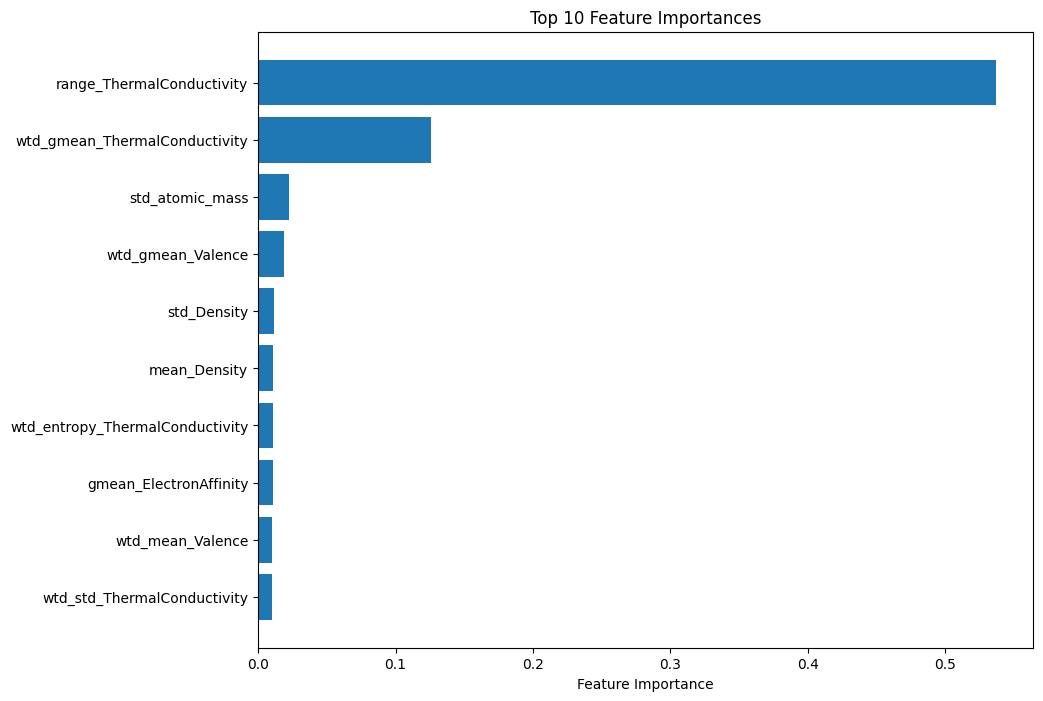

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data = pd.read_csv('train.csv')

X = data.drop(columns=['critical_temp'])
y = data['critical_temp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#best parameters from hyperparameter tuning
best_params = {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
model = RandomForestRegressor(
    random_state=42,
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    n_estimators=best_params['n_estimators']
)
model.fit(X_train, y_train)


feature_importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances')
plt.show()


As expected the most impactful features have to do with thermal conductivity since its highly correlated with critical temperature . Since our dataset consists of 82 features we will try training our model for the top impactful features to find a good balance between accuracy and minimize computation cost.

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from math import sqrt
results = {"Number of Features": [], "RMSE": [], "R²": []}

print("\nModel Performance for Different Subsets of Top Features:")
for n in [5,10,15,20,30,50,70,82]:  # Test with top 1 to top 10 features
    top_features = importance_df['Feature'][:n]
    X_train_subset = X_train[top_features]
    X_test_subset = X_test[top_features]
    
   
    model_subset = RandomForestRegressor(
        random_state=42,
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        n_estimators=best_params['n_estimators']
    )
    model_subset.fit(X_train_subset, y_train)
    
   
    
    y_pred_subset = model_subset.predict(X_test_subset)
    rmse = sqrt(mean_squared_error(y_test, y_pred_subset))
    r2 = r2_score(y_test, y_pred_subset)
    
    print(f"Top {n} Features:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²: {r2:.2f}")
    results["Number of Features"].append(n)
    results["RMSE"].append(rmse)
    results["R²"].append(r2)


Model Performance for Different Subsets of Top Features:
Top 5 Features:
  RMSE: 10.25
  R²: 0.91
Top 10 Features:
  RMSE: 9.68
  R²: 0.92
Top 15 Features:
  RMSE: 9.42
  R²: 0.92
Top 20 Features:
  RMSE: 9.14
  R²: 0.93
Top 30 Features:
  RMSE: 9.07
  R²: 0.93
Top 50 Features:
  RMSE: 9.00
  R²: 0.93
Top 70 Features:
  RMSE: 8.96
  R²: 0.93
Top 82 Features:
  RMSE: 8.95
  R²: 0.93


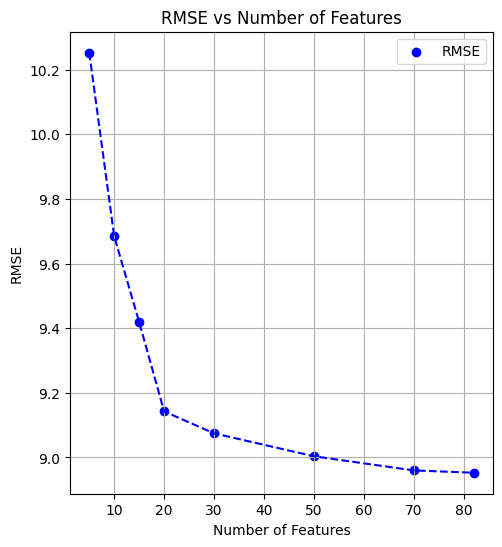

In [ ]:
plt.figure(figsize=(12, 6))

# Scatter plot for RMSE
plt.subplot(1, 2, 1)
plt.scatter(results["Number of Features"], results["RMSE"], color="blue", label="RMSE")
plt.plot(results["Number of Features"], results["RMSE"], linestyle="--", color="blue")
plt.xlabel("Number of Features")
plt.ylabel("RMSE")
plt.title("RMSE vs Number of Features")
plt.grid(True)
plt.legend()

100%|===================| 17008/17010 [134:07<00:00]        

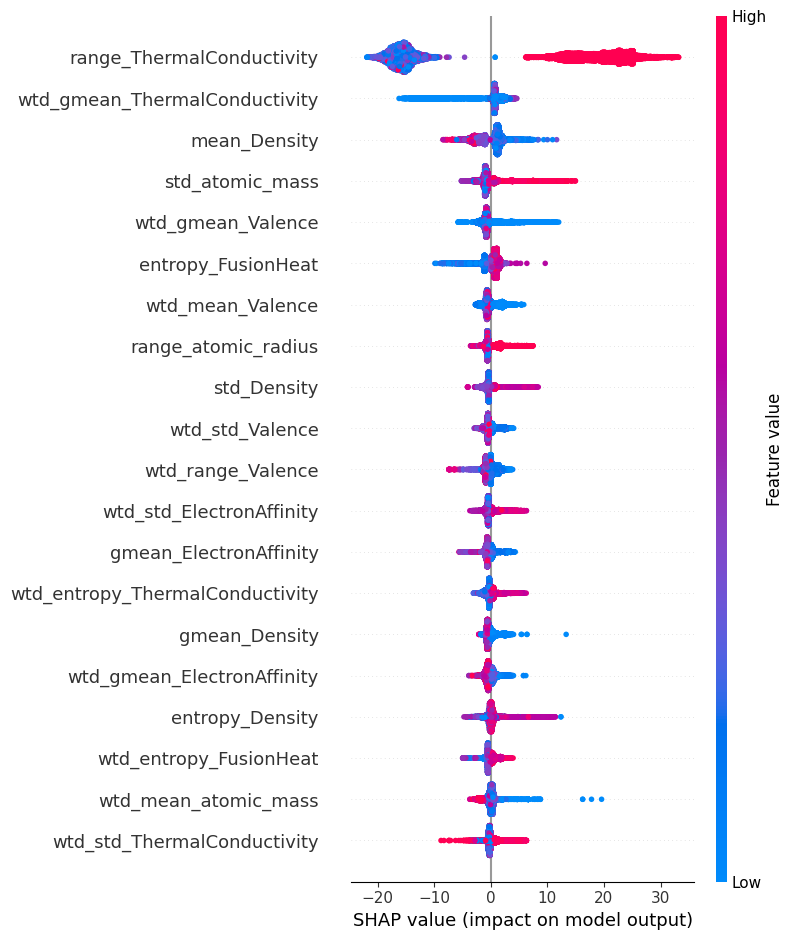

In [6]:
import shap


explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_train, check_additivity=False)

# Summary plot of SHAP values for feature importance
shap.summary_plot(shap_values, X_train)


Model Performance for Different Subsets of Top SHAP Features:


Top 5 Features:
  RMSE: 10.31
  R²: 0.91
Top 10 Features:
  RMSE: 9.67
  R²: 0.92
Top 15 Features:
  RMSE: 9.29
  R²: 0.92
Top 20 Features:
  RMSE: 9.23
  R²: 0.93
Top 30 Features:
  RMSE: 9.08
  R²: 0.93
Top 50 Features:
  RMSE: 8.97
  R²: 0.93
Top 70 Features:
  RMSE: 8.96
  R²: 0.93
Top 81 Features:
  RMSE: 8.95
  R²: 0.93


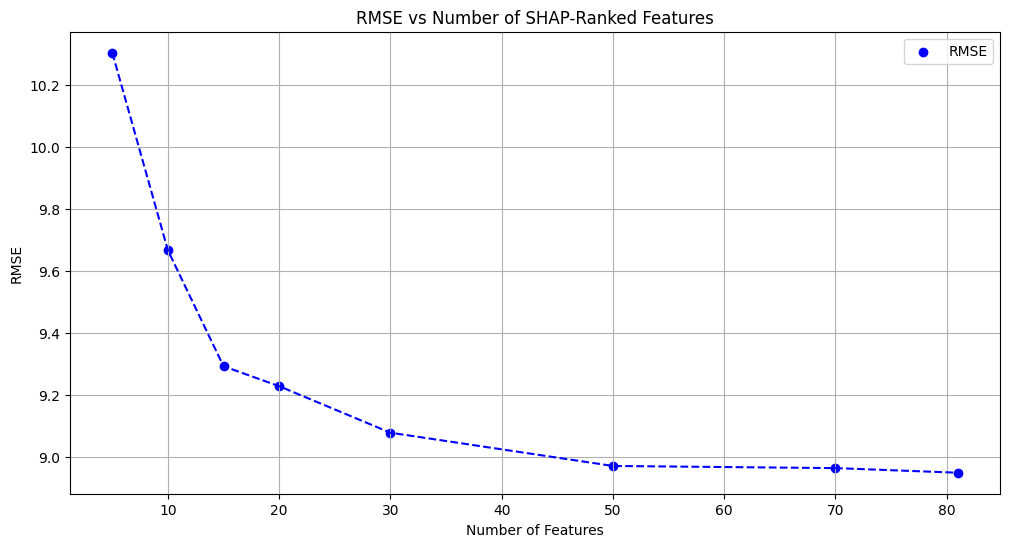

In [7]:
import numpy as np

shap_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean SHAP Value': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='Mean SHAP Value', ascending=False)


results = {"Number of Features": [], "RMSE": [], "R²": []}


print("\nModel Performance for Different Subsets of Top SHAP Features:")
for n in [5, 10, 15, 20, 30, 50, 70, len(shap_importance)]:
    top_features = shap_importance['Feature'][:n]
    X_train_subset = X_train[top_features]
    X_test_subset = X_test[top_features]

   
    model_subset = RandomForestRegressor(
        random_state=42,
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        n_estimators=best_params['n_estimators']
    )
    model_subset.fit(X_train_subset, y_train)

   
    y_pred_subset = model_subset.predict(X_test_subset)
    rmse = sqrt(mean_squared_error(y_test, y_pred_subset))
    r2 = r2_score(y_test, y_pred_subset)

    print(f"Top {n} Features:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²: {r2:.2f}")
    results["Number of Features"].append(n)
    results["RMSE"].append(rmse)
    results["R²"].append(r2)

# Plot RMSE vs Number of Features
plt.figure(figsize=(12, 6))
plt.scatter(results["Number of Features"], results["RMSE"], color="blue", label="RMSE")
plt.plot(results["Number of Features"], results["RMSE"], linestyle="--", color="blue")
plt.xlabel("Number of Features")
plt.ylabel("RMSE")
plt.title("RMSE vs Number of SHAP-Ranked Features")
plt.grid(True)
plt.legend()
plt.show()



# Anomaly detection

For the purposes of anomaly detection we decided to use two different approaches.

- in the first approach we are going to use SVM in order to track anomalies in respect of all the features included in the dataset.

- in the latter approach we are going to use the Isolation Forest in order to track anomalies regarding the critical temperature in respect to the mean_atomic_mass.

## SVM for all features and PCA dimensionality reduction and t-SNE

In [ ]:
# Imports:
import pandas as pd
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE 
from time import time
from sklearn.ensemble import IsolationForest

Training time: 0.47 seconds
Number of anomalies detected (excluding critical_temp=0): 215


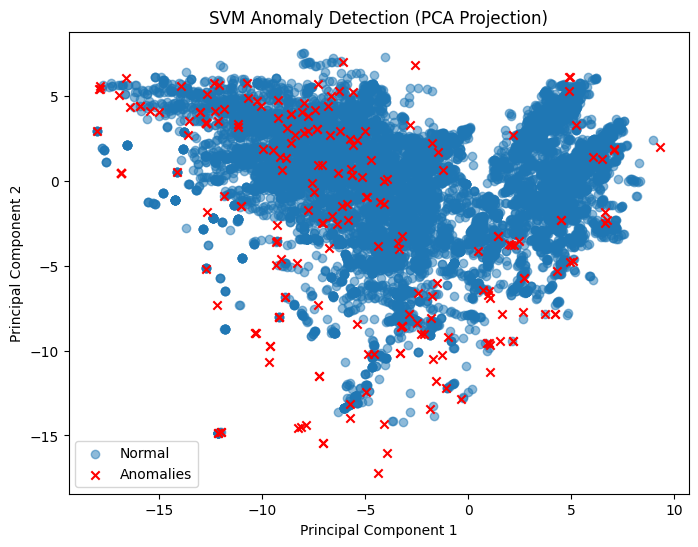

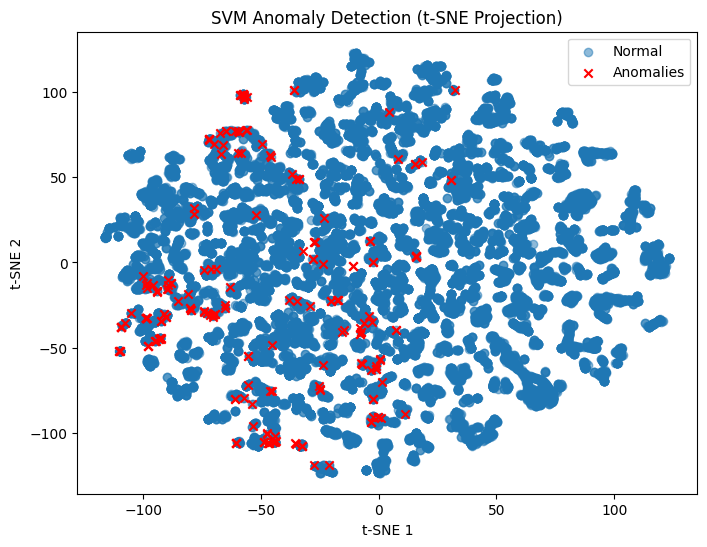

In [ ]:
df = pd.read_csv('train.csv')


features = df.columns.tolist()



scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Creation and training
start_time = time()
model = OneClassSVM(kernel='rbf', nu=0.01)  # Assume ~1% anomalous datapoints
model.fit(X_scaled)
end_time = time()
print(f"Training time: {end_time - start_time:.2f} seconds")

# Predictions
predictions = model.predict(X_scaled)


df['anomaly'] = predictions

# Exclude outliers with critical_temp=0
anomalies = df[df['anomaly'] == -1]
anomalies = anomalies[anomalies['critical_temp'] != 0]


print("Number of anomalies detected (excluding critical_temp=0):", len(anomalies))

# Dimensionality Reduction for Visualization (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['anomaly'] = df['anomaly']

# PCA Plot
plt.figure(figsize=(8, 6))
plt.scatter(df_pca[df_pca['anomaly'] == 1]['PC1'], df_pca[df_pca['anomaly'] == 1]['PC2'], label='Normal', alpha=0.5)
plt.scatter(df_pca[df_pca['anomaly'] == -1]['PC1'], df_pca[df_pca['anomaly'] == -1]['PC2'],
            color='red', label='Anomalies', marker='x')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('SVM Anomaly Detection (PCA Projection)')
plt.legend()

# t-SNE for Visualization
tsne = TSNE(n_components=2, random_state=42)  # Set random state for reproducibility
X_tsne = tsne.fit_transform(X_scaled)
df_tsne = pd.DataFrame(X_tsne, columns=['t-SNE 1', 't-SNE 2'])
df_tsne['anomaly'] = df['anomaly']

# t-SNE Plot
plt.figure(figsize=(8, 6))
plt.scatter(df_tsne[df_tsne['anomaly'] == 1]['t-SNE 1'], df_tsne[df_tsne['anomaly'] == 1]['t-SNE 2'], label='Normal', alpha=0.5)
plt.scatter(df_tsne[df_tsne['anomaly'] == -1]['t-SNE 1'], df_tsne[df_tsne['anomaly'] == -1]['t-SNE 2'],
            color='red', label='Anomalies', marker='x')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('SVM Anomaly Detection (t-SNE Projection)')
plt.legend()

plt.show()

## Isolation Forest

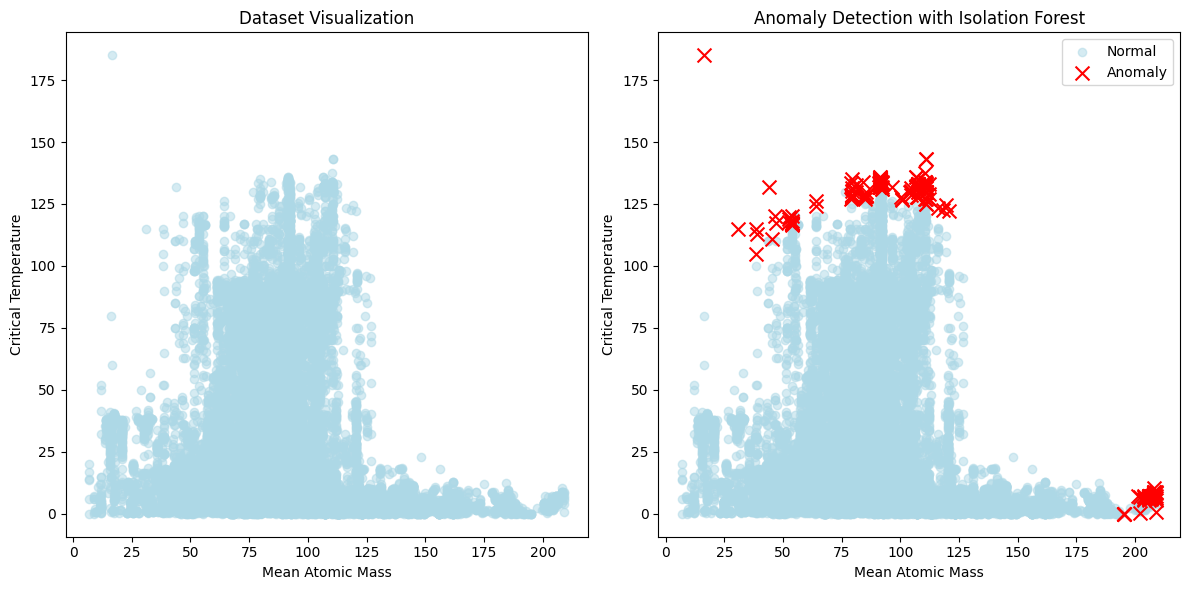

Number of anomalies detected: 213


In [ ]:
from sklearn.ensemble import IsolationForest


def filter_critical_temp_zero(data, features):
  """makes datapoints with 0 critical temperature exclusions to anomalies

  Input:
      The original data.
      

  Output:
      The filtered data 
  """
  return data[data['critical_temp'] != 0][features]


data = pd.read_csv('train.csv')

features = ['mean_atomic_mass', 'critical_temp']

# Data filtering
data_filtered = filter_critical_temp_zero(data.copy(), features.copy())  

# Model creation and fit
model = IsolationForest(contamination=0.01)  # Assuming around 1% anomalous datapoints from previous visualisation
model.fit(data_filtered)

# Predictions 
data['anomaly'] = model.predict(data[features])

# Plots
plt.figure(figsize=(12, 6))

# Dataset
plt.subplot(1, 2, 1)
plt.scatter(data['mean_atomic_mass'], data['critical_temp'], color='lightblue', alpha=0.5)
plt.xlabel('Mean Atomic Mass')
plt.ylabel('Critical Temperature')
plt.title('Dataset Visualization')

# Dataset with highlighted anomalies
plt.subplot(1, 2, 2)
plt.scatter(data[data['anomaly'] == 1]['mean_atomic_mass'],
            data[data['anomaly'] == 1]['critical_temp'],
            color='lightblue', alpha=0.5, label='Normal')
plt.scatter(data[data['anomaly'] == -1]['mean_atomic_mass'],
            data[data['anomaly'] == -1]['critical_temp'],
            color='red', marker='x', s=100, label='Anomaly')
plt.xlabel('Mean Atomic Mass')
plt.ylabel('Critical Temperature')
plt.title('Anomaly Detection with Isolation Forest')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Number of anomalies detected: {len(data[data['anomaly'] == -1])}")

# SYNTHESIS

In this section we will try to predict new superconductors using the second file from the dataset that contains the chemical compositions of each material described in the first file. We will try to produce  new combinations of chemical elements and evaluate them based on a random forest model trained on a merged dataset containing all of the information from both files.Through a bayesian optimization algorithm our script should explore and extract the best candidates with high critical temperatures.We will impose some constrains by a penalty system , specifically a maximum number of components and having at least one transition metal.

Train data shape: (21263, 82)
Unique materials shape: (21263, 87)
Merged data shape: (21263, 169)
Feature columns: ['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass', 'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass', 'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie', 'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie', 'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie', 'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius', 'wtd_gmean_atomic_radius', 'entropy_atomic_radius', 'wtd_entropy_atomic_radius', 'range_atomic_radius', 'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius', 'mean_Density', 'wtd_mean_Density', 'gmean_Density', 'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density', 'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density', 'mean_ElectronAffinity', 'wtd_mean_ElectronAffinit

Optimizing: 100%|██████████| 300/300 [3:16:07<00:00, 39.22s/it]   


Optimal Material Composition (0/1): [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Predicted Tc: 33.24662848719903


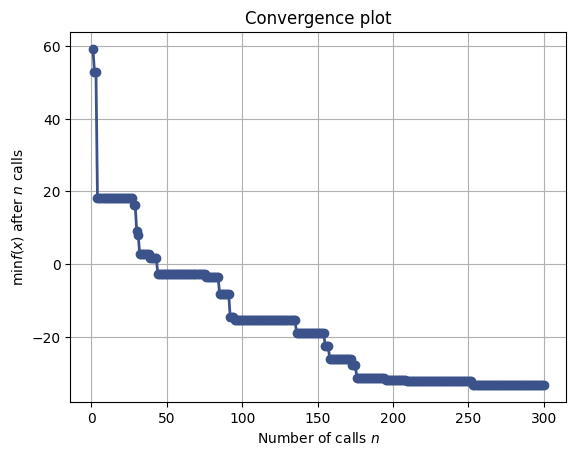

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from skopt import gp_minimize
from skopt.space import Integer
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler


train_data = pd.read_csv('train.csv')
unique_materials = pd.read_csv('unique_m.csv')


if 'critical_temp' in unique_materials.columns:
    unique_materials.drop(columns=['critical_temp'], inplace=True)


# unique_m has columns like ["Al", "Fe", "Cu", ...]
composition_features = unique_materials.columns[:-1].tolist()

# Convert any values > 0 into 1, else 0
unique_materials[composition_features] = (
    unique_materials[composition_features] > 0
).astype(int)

# Now unique_materials are strictly 0/1 in composition_features.

# Merge datasets
data = pd.concat([train_data, unique_materials], axis=1)

print("Train data shape:", train_data.shape)
print("Unique materials shape:", unique_materials.shape)
print("Merged data shape:", data.shape)

X = data.drop(columns=['critical_temp', 'material']) 
y = data['critical_temp'] 

print("Feature columns:", list(X.columns))
print("Target column:", y.name)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# surrogate model
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)


predictions = rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", rmse)


search_space = [Integer(0, 1, name=feature) for feature in composition_features]

print("Composition features:", composition_features)
print("Search space dimensions:", len(search_space))


MAX_COMPONENTS = 4 
transition_metals = [
    'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 
    'Ni', 'Cu', 'Zn', 'Nb', 'Mo', 'Tc', 'Ru', 
    'Rh', 'Pd', 'Ag', 'Cd'
]

@use_named_args(search_space)
def objective(**kwargs):
    """
    Returns a negative predicted Tc with penalties applied for
    exceeding MAX_COMPONENTS or lacking a transition metal.
    """

    candidate_composition = np.array([
        kwargs[feature] for feature in composition_features
    ]).reshape(1, -1)
    candidate_features = pd.DataFrame(candidate_composition, columns=composition_features)


    for col in X.columns:
        if col not in candidate_features:
            candidate_features[col] = 0


    candidate_features = candidate_features[X.columns]

 
    predicted_tc = rf.predict(candidate_features)[0]


    num_components = sum(kwargs[feature] for feature in composition_features)


    contains_transition_metal = any(kwargs[element] == 1 for element in transition_metals)


    penalty = 0
    if num_components > MAX_COMPONENTS:
        penalty += (num_components - MAX_COMPONENTS) * 1.8
    if not contains_transition_metal:
        penalty += 50

    #  Return negative predicted Tc plus penalty

    return float(max(-predicted_tc + penalty, -100))

n_calls = 300  
with tqdm(total=n_calls, desc="Optimizing") as pbar:
    def callback(res):
        pbar.update(1)

    result = gp_minimize(
        objective, 
        search_space, 
        n_calls=n_calls, 
        random_state=42, 
        callback=[callback]
    )


optimal_candidate = result.x
optimal_tc = -result.fun

print("Optimal Material Composition (0/1):", optimal_candidate)
print("Predicted Tc:", optimal_tc)


plot_convergence(result);


In [ ]:
optimal_formula = "".join(
    f"{element}" if included else "" for element, included in zip(composition_features, optimal_candidate)
)

print("Optimal Material Composition (binary):", optimal_candidate)
print("Chemical Formula of Optimal Material:", optimal_formula)
print("Predicted Tc:", optimal_tc)

Optimal Material Composition (binary): [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Chemical Formula of Optimal Material: HAlArMo
Predicted Tc: 33.24662848719903


We will try to change the number of components for achieving better results

In [ ]:
MAX_COMPONENTS = 3
transition_metals = [
    'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 
    'Ni', 'Cu', 'Zn', 'Nb', 'Mo', 'Tc', 'Ru', 
    'Rh', 'Pd', 'Ag', 'Cd'
]
composition_features = unique_materials.columns[:-1].tolist()
@use_named_args(search_space)
def objective(**kwargs):
    """
    Returns a negative predicted Tc with penalties applied for
    exceeding MAX_COMPONENTS or lacking a transition metal.
    """

    candidate_composition = np.array([
        kwargs[feature] for feature in composition_features
    ]).reshape(1, -1)
    candidate_features = pd.DataFrame(candidate_composition, columns=composition_features)


    for col in X.columns:
        if col not in candidate_features:
            candidate_features[col] = 0


    candidate_features = candidate_features[X.columns]


    predicted_tc = rf.predict(candidate_features)[0]


    num_components = sum(kwargs[feature] for feature in composition_features)

    contains_transition_metal = any(kwargs[element] == 1 for element in transition_metals)


    penalty = 0
    if num_components > MAX_COMPONENTS:
        penalty += (num_components - MAX_COMPONENTS) * 1.8
    if not contains_transition_metal:
        penalty += 50


    return float(max(-predicted_tc + penalty, -100))


n_calls = 180  
with tqdm(total=n_calls, desc="Optimizing") as pbar:
    def callback(res):
        pbar.update(1)

    result = gp_minimize(
        objective, 
        search_space, 
        n_calls=n_calls, 
        random_state=42, 
        callback=[callback]
    )

optimal_candidate = result.x
optimal_tc = -result.fun

print("Optimal Material Composition (0/1):", optimal_candidate)
print("Predicted Tc:", optimal_tc)


Optimizing: 100%|██████████| 180/180 [28:01<00:00,  9.34s/it]

Optimal Material Composition (0/1): [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Predicted Tc: 32.10312848719903


In [ ]:
optimal_formula = "".join(
    f"{element}" if included else "" for element, included in zip(composition_features, optimal_candidate)
)

# Print the results
print("Optimal Material Composition (binary):", optimal_candidate)
print("Chemical Formula of Optimal Material:", optimal_formula)
print("Predicted Tc:", optimal_tc)

Optimal Material Composition (binary): [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Chemical Formula of Optimal Material: HeMnZn
Predicted Tc: 32.10312848719903
